In [1]:
import h5py
import numpy as np

# 加载保存的结果文件
with h5py.File('slidewindow2_pseudocorrelation_slface.h5', 'r') as f:
    # 加载z相关矩阵
    z_correlations_real1 = f['z_correlations_real'][:]

# 打印形状
print("z_correlations_real shape:", z_correlations_real1.shape)

import numpy as np
import statsmodels.api as sm
import pandas as pd

# 提取对角线元素，得到形状 (400, 46, 23, 12)
diagonal_values1 = np.array([np.diagonal(z_correlations_real1[i], axis1=-2, axis2=-1) for i in range(400)])

# 维度检查 (400, 46, 23, 12)
assert diagonal_values1.shape == (400, 23, 46,22, 12), "数据维度错误"
diagonal_values_avg1 = diagonal_values1.mean(axis=-1)  # 维度从 (400, 46, 23, 12) → (400, 46, 23)
diagonal_values_avgpair = diagonal_values_avg1.mean(axis=-1)  



z_correlations_real shape: (400, 23, 46, 22, 12, 12)


/home/sylsherry/miniconda3/envs/tfgpu/lib/python3.9/site-packages/numpy/core/_methods.py:118: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


In [2]:
import h5py
import numpy as np

# 加载保存的结果文件
#with h5py.File('slidewindow_correlation_results.h5', 'r') as f:
with h5py.File('slidewindow2_realcorrelation_slface.h5', 'r') as f:

    # 加载z相关矩阵
    z_correlations_real2 = f['z_correlations_real'][:]

# 打印形状
print("z_correlations_real shape:", z_correlations_real2.shape)
import numpy as np
import statsmodels.api as sm
import pandas as pd

# 提取对角线元素，得到形状 (400, 46, 23, 12)
diagonal_values2 = np.array([np.diagonal(z_correlations_real2[i], axis1=-2, axis2=-1) for i in range(400)])

# 维度检查 (400, 46, 23, 12)
assert diagonal_values2.shape == (400, 23, 46, 12), "数据维度错误"
diagonal_values_avg = diagonal_values2.mean(axis=-1)  # 维度从 (400, 46, 23, 12) → (400, 46, 2|3)



z_correlations_real shape: (400, 23, 46, 12, 12)


In [4]:
import numpy as np
import pandas as pd
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

# 启用 Pandas 与 R DataFrame 互操作
pandas2ri.activate()
real=set(real)
# 存储所有脑区的混合效应结果
results_list = []

for region in real:
    print(f"Processing region {region}")

    data_list = []
    for subject in range(46):
        for t in range(23):
            condition = 1 if t < 9 else 2
            time_in_condition = t if t < 9 else t - 9

            # 获取真实配对的 y 值
            y_real = diagonal_values_avg[region, t, subject]
            # 获取 pseudo（非真实配对）的 y 值
            y_pseudo = diagonal_values_avgpair[region, t, subject]  
            stimulus_group = 2 if subject >= 23 else 1  # 标记 StimulusGroup

            # 存入数据
            data_list.append([subject, t, time_in_condition, condition, y_pseudo, 0, stimulus_group])  # 非真实配对
            data_list.append([subject, t, time_in_condition, condition, y_real, 1, stimulus_group])  # 真实配对

    df_region = pd.DataFrame(data_list, columns=["Subject", "GlobalTime", "Time", "Condition", "y", "PairType", "StimulusGroup"])
    df_region = df_region.dropna()
    if df_region.empty:
        print(f"Skipping region {region} due to empty dataframe after dropna")
        continue

    df_region["Subject"] = df_region["Subject"].astype(str)  # R `lme4` 需要因子变量

    # 放大 y 值，避免数值计算问题
    df_region["y"] = df_region["y"] * 10   

    # 转换为 R DataFrame
    r_df = pandas2ri.py2rpy(df_region)

    # 确保 Python 传递数据到 R
    ro.globalenv["df"] = r_df

    r_code = """
    library(lme4)

    # 确保变量是 factor
    df$PairType <- as.factor(df$PairType)
    df$Condition <- as.factor(df$Condition)
    df$StimulusGroup <- as.factor(df$StimulusGroup)

    # 创建两个不同的模型：一个带交互项，一个只有主效应
    
    # 模型1：带交互项的模型 (Time * PairType)
    model_interaction <- tryCatch(
        lmer(y ~ Time * PairType + Condition + StimulusGroup + (1 | Subject), data=df, REML=FALSE),
        error = function(e) NA,
        warning = function(w) {
            # 对于警告，仍然尝试返回模型
            tryCatch(
                lmer(y ~ Time * PairType + Condition + StimulusGroup + (1 | Subject), data=df, REML=FALSE),
                error = function(e) NA
            )
        }
    )
    
    # 模型2：只有主效应的模型 (无交互项)
    model_main_effects <- tryCatch(
        lmer(y ~ Time + PairType + Condition + StimulusGroup + (1 | Subject), data=df, REML=FALSE),
        error = function(e) NA,
        warning = function(w) {
            # 对于警告，仍然尝试返回模型
            tryCatch(
                lmer(y ~ Time + PairType + Condition + StimulusGroup + (1 | Subject), data=df, REML=FALSE),
                error = function(e) NA
            )
        }
    )
    
    # 如果两个模型中任一个无法收敛，停止
    if (is.na(model_interaction)[1] || is.na(model_main_effects)[1]) {
        stop("至少一个模型无法收敛")
    }
    
    # 检查 Singular Fit（仅用于诊断）
    singular_fit_interaction <- isSingular(model_interaction)
    singular_fit_main <- isSingular(model_main_effects)
    
    # 提取模型1（交互模型）的系数
    real_interaction_coef <- fixef(model_interaction)["Time:PairType1"]
    
    # 提取模型2（主效应模型）的系数
    real_pairtype_main_coef <- fixef(model_main_effects)["PairType1"]
    real_time_main_coef <- fixef(model_main_effects)["Time"]

    # 保存原始数据副本用于置换
    df_orig <- df

    N_PERMUTATIONS <- 3000  
    # 为交互模型创建结果存储
    perm_inter_coefs <- numeric(N_PERMUTATIONS)
    
    # 为主效应模型创建结果存储
    perm_pairtype_main_coefs <- numeric(N_PERMUTATIONS)
    perm_time_main_coefs <- numeric(N_PERMUTATIONS)
    
    valid_perms_interaction <- 0  # 交互模型有效置换计数
    valid_perms_main <- 0  # 主效应模型有效置换计数
    
    for (i in 1:N_PERMUTATIONS) {
        # 复制原始数据
        df_perm <- df_orig
        
        # 对于每个被试和每个条件独立地置换PairType标签
        for (subj in unique(df_perm$Subject)) {
            for (cond in unique(df_perm$Condition)) {
                # 获取该被试在该条件下的数据索引
                indices <- which(df_perm$Subject == subj & df_perm$Condition == cond)
                
                if (length(indices) > 1) {  # 确保有足够的数据点进行置换
                    # 随机打乱PairType标签
                    df_perm$PairType[indices] <- sample(df_perm$PairType[indices])
                }
            }
        }
        
        # 拟合交互模型
        perm_model_interaction <- tryCatch(
            lmer(y ~ Time * PairType + Condition + StimulusGroup + (1 | Subject), data=df_perm, REML=FALSE),
            error = function(e) NA,
            warning = function(w) {
                # 对于警告，仍然尝试返回模型
                tryCatch(
                    lmer(y ~ Time * PairType + Condition + StimulusGroup + (1 | Subject), data=df_perm, REML=FALSE),
                    error = function(e) NA
                )
            }
        )
        
        # 拟合主效应模型
        perm_model_main <- tryCatch(
            lmer(y ~ Time + PairType + Condition + StimulusGroup + (1 | Subject), data=df_perm, REML=FALSE),
            error = function(e) NA,
            warning = function(w) {
                # 对于警告，仍然尝试返回模型
                tryCatch(
                    lmer(y ~ Time + PairType + Condition + StimulusGroup + (1 | Subject), data=df_perm, REML=FALSE),
                    error = function(e) NA
                )
            }
        )
        
        # 提取交互模型结果
        if (!is.na(perm_model_interaction)[1]) {
            valid_perms_interaction <- valid_perms_interaction + 1
            # 提取交互系数
            perm_inter_coefs[i] <- fixef(perm_model_interaction)["Time:PairType1"]
        } else {
            # 模型拟合失败，将系数设为NA
            perm_inter_coefs[i] <- NA
        }
        
        # 提取主效应模型结果
        if (!is.na(perm_model_main)[1]) {
            valid_perms_main <- valid_perms_main + 1
            # 提取主效应系数
            perm_pairtype_main_coefs[i] <- fixef(perm_model_main)["PairType1"]
            perm_time_main_coefs[i] <- fixef(perm_model_main)["Time"]
        } else {
            # 模型拟合失败，将系数设为NA
            perm_pairtype_main_coefs[i] <- NA
            perm_time_main_coefs[i] <- NA
        }
        
        # 每500次置换显示进度
        if (i %% 500 == 0) {
            cat("完成 ", i, " 次置换, 交互模型有效: ", valid_perms_interaction, 
                ", 主效应模型有效: ", valid_perms_main, "\n")
        }
    }

    # 去除 NA 结果
    perm_inter_coefs_clean <- perm_inter_coefs[!is.na(perm_inter_coefs)]
    perm_pairtype_main_coefs_clean <- perm_pairtype_main_coefs[!is.na(perm_pairtype_main_coefs)]
    perm_time_main_coefs_clean <- perm_time_main_coefs[!is.na(perm_time_main_coefs)]

    # 计算正向单侧 permutation p 值
    p_value_inter_perm <- mean(perm_inter_coefs_clean >= real_interaction_coef)
    p_value_pairtype_main_perm <- mean(perm_pairtype_main_coefs_clean >= real_pairtype_main_coef)    
    p_value_time_main_perm <- mean(perm_time_main_coefs_clean >= real_time_main_coef)
    
    # 有效置换比例
    valid_ratio_interaction <- valid_perms_interaction / N_PERMUTATIONS
    valid_ratio_main <- valid_perms_main / N_PERMUTATIONS
    
    list(
        # 模型1（交互效应）结果
        intercept_interaction = fixef(model_interaction)["(Intercept)"],
        time_interaction = fixef(model_interaction)["Time"],
        pair_interaction = fixef(model_interaction)["PairType1"],
        interaction_effect = real_interaction_coef,
        p_inter_perm = p_value_inter_perm,
        valid_perms_interaction = valid_perms_interaction,
        valid_ratio_interaction = valid_ratio_interaction,
        singular_fit_interaction = singular_fit_interaction,
        
        # 模型2（主效应）结果
        intercept_main = fixef(model_main_effects)["(Intercept)"],
        time_main_effect = real_time_main_coef,
        pair_main_effect = real_pairtype_main_coef,
        p_time_main_perm = p_value_time_main_perm,
        p_pair_main_perm = p_value_pairtype_main_perm,
        valid_perms_main = valid_perms_main,
        valid_ratio_main = valid_ratio_main,
        singular_fit_main = singular_fit_main
    )
    """

    try:
        r_results = ro.r(r_code)  # 执行 R 代码
        results_list.append([
            region,
            # 交互模型结果 
            r_results[0],  # intercept_interaction
            r_results[1],  # time_interaction
            r_results[2],  # pair_interaction
            r_results[3],  # interaction_effect
            r_results[4],  # p_inter_perm
            r_results[5],  # valid_perms_interaction
            r_results[6],  # valid_ratio_interaction
            r_results[7],  # singular_fit_interaction
            
            # 主效应模型结果
            r_results[8],  # intercept_main
            r_results[9],  # time_main_effect
            r_results[10], # pair_main_effect
            r_results[11], # p_time_main_perm
            r_results[12], # p_pair_main_perm
            r_results[13], # valid_perms_main
            r_results[14], # valid_ratio_main
            r_results[15]  # singular_fit_main
        ])
        print(f"Successfully processed region {region}")

    except Exception as e:
        print(f"Skipping region {region} due to error: {e}")
        continue

# 创建结果 DataFrame
df_results = pd.DataFrame(results_list, columns=[
    "Brain_Region", 
    # 交互模型结果
    "Intercept_Interaction", "Time_Effect_Interaction", "Pair_Effect_Interaction", "TimePair_Effect",
    "TimePair_p_perm", "Valid_Perms_Interaction", "Valid_Ratio_Interaction", "Singular_Fit_Interaction",
    
    # 主效应模型结果
    "Intercept_Main", "Time_Effect_Main", "Pair_Effect_Main",
    "Time_p_main_perm", "PairType_p_main_perm", 
    "Valid_Perms_Main", "Valid_Ratio_Main", "Singular_Fit_Main"
])

# 保存结果
#df_results.to_csv("pair_comparison_results_separate_models.csv", index=False)

# 应用 FDR 校正
from statsmodels.stats.multitest import multipletests

# 对各p值进行FDR校正
df_results["Time_Main_p_FDR"] = multipletests(df_results["Time_p_main_perm"], method="fdr_bh")[1]
df_results["PairType_Main_p_FDR"] = multipletests(df_results["PairType_p_main_perm"], method="fdr_bh")[1]
df_results["TimePair_p_FDR"] = multipletests(df_results["TimePair_p_perm"], method="fdr_bh")[1]

# 保存带FDR校正的结果
#df_results.to_csv("pair_comparison_results_separate_models_with_FDR_win4.csv", index=False)

# 筛选结果
alpha = 0.05  # 显著性水平

# 找出PairType主效应显著且为正的脑区（实配对>假配对）
significant_pair = df_results[
    (df_results["PairType_Main_p_FDR"] < alpha) & 
    (df_results["Pair_Effect_Main"] > 0)
]
print(f"找到{len(significant_pair)}个实配对显著高于假配对的脑区（来自主效应模型）")

# 找出Time:PairType交互效应显著且为正的脑区（实配对的时间效应>假配对）
significant_interaction = df_results[
    (df_results["TimePair_p_FDR"] < alpha) & 
    (df_results["TimePair_Effect"] > 0)
]
print(f"找到{len(significant_interaction)}个实配对的时间效应显著强于假配对的脑区（来自交互效应模型）")

# 同时满足上述两个条件的脑区
significant_both = df_results[
    (df_results["PairType_Main_p_FDR"] < alpha) & 
    (df_results["Pair_Effect_Main"] > 0) &
    (df_results["TimePair_p_FDR"] < alpha) & 
    (df_results["TimePair_Effect"] > 0)
]
print(f"找到{len(significant_both)}个脑区同时满足：实配对水平更高（主效应模型）且时间效应更强（交互效应模型）")

R[write to console]: Loading required package: Matrix



Processing region 352
完成  500  次置换, 交互模型有效:  500 , 主效应模型有效:  500 
完成  1000  次置换, 交互模型有效:  1000 , 主效应模型有效:  1000 
完成  1500  次置换, 交互模型有效:  1500 , 主效应模型有效:  1500 
完成  2000  次置换, 交互模型有效:  2000 , 主效应模型有效:  2000 
完成  2500  次置换, 交互模型有效:  2500 , 主效应模型有效:  2500 
完成  3000  次置换, 交互模型有效:  3000 , 主效应模型有效:  3000 


R[write to console]: In addition: 
R[write to console]: There were 50 or more warnings (use warnings() to see the first 50)
R[write to console]: 



Successfully processed region 352
Processing region 66
完成  500  次置换, 交互模型有效:  500 , 主效应模型有效:  500 
完成  1000  次置换, 交互模型有效:  1000 , 主效应模型有效:  1000 
完成  1500  次置换, 交互模型有效:  1500 , 主效应模型有效:  1500 
完成  2000  次置换, 交互模型有效:  2000 , 主效应模型有效:  2000 
完成  2500  次置换, 交互模型有效:  2500 , 主效应模型有效:  2500 
完成  3000  次置换, 交互模型有效:  3000 , 主效应模型有效:  3000 


R[write to console]: In addition: 
R[write to console]: There were 50 or more warnings (use warnings() to see the first 50)
R[write to console]: 



...

Successfully processed region 144
Processing region 94
完成  500  次置换, 交互模型有效:  500 , 主效应模型有效:  500 
完成  1000  次置换, 交互模型有效:  1000 , 主效应模型有效:  1000 
完成  1500  次置换, 交互模型有效:  1500 , 主效应模型有效:  1500 
完成  2000  次置换, 交互模型有效:  2000 , 主效应模型有效:  2000 
完成  2500  次置换, 交互模型有效:  2500 , 主效应模型有效:  2500 
完成  3000  次置换, 交互模型有效:  3000 , 主效应模型有效:  3000 


R[write to console]: In addition: 
R[write to console]: There were 50 or more warnings (use warnings() to see the first 50)
R[write to console]: 



Successfully processed region 94
Processing region 351
完成  500  次置换, 交互模型有效:  500 , 主效应模型有效:  500 
完成  1000  次置换, 交互模型有效:  1000 , 主效应模型有效:  1000 
完成  1500  次置换, 交互模型有效:  1500 , 主效应模型有效:  1500 
完成  2000  次置换, 交互模型有效:  2000 , 主效应模型有效:  2000 
完成  2500  次置换, 交互模型有效:  2500 , 主效应模型有效:  2500 
完成  3000  次置换, 交互模型有效:  3000 , 主效应模型有效:  3000 


R[write to console]: In addition: 
R[write to console]: There were 50 or more warnings (use warnings() to see the first 50)
R[write to console]: 



Successfully processed region 351
找到5个实配对显著高于假配对的脑区（来自主效应模型）
找到3个实配对的时间效应显著强于假配对的脑区（来自交互效应模型）
找到2个脑区同时满足：实配对水平更高（主效应模型）且时间效应更强（交互效应模型）


创建了区域 13 的图表


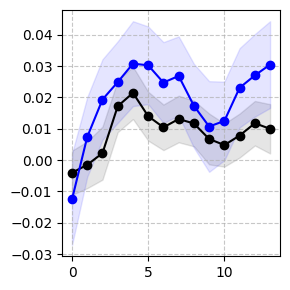

创建了区域 15 的图表


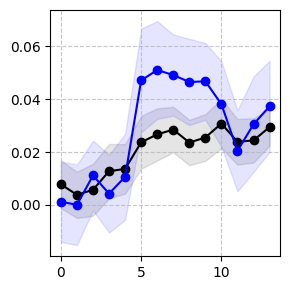

创建了区域 66 的图表


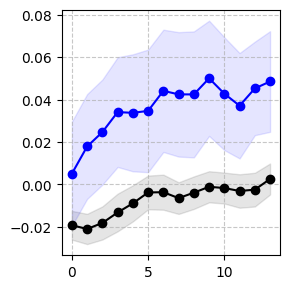

创建了区域 142 的图表


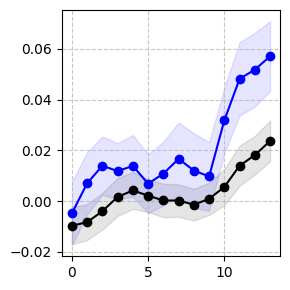

创建了区域 144 的图表


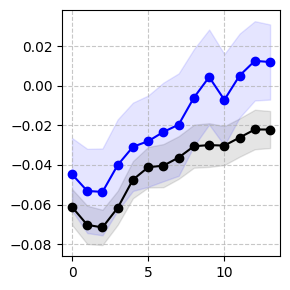

所有图表创建完成


In [9]:
import matplotlib.pyplot as plt
import numpy as np

import numpy as np
import matplotlib.pyplot as plt

# 指定的区域列表
regions = [13, 15, 66, 142, 144]

# 为每个区域创建图表
for region in regions:
    # 创建一个图
    plt.figure(figsize=(3, 3))
    
    # 第一条曲线: diagonal_values_avgpair，黑色线
    mean_values1 = np.mean(diagonal_values_avgpair, axis=2)[region][9:]
    se_values1 = np.std(diagonal_values_avgpair, axis=2)[region][9:] / (np.sqrt(diagonal_values_avgpair.shape[2])-1)
    x1 = np.arange(len(mean_values1))
    plt.plot(x1, mean_values1, marker='o', linestyle='-', color='k')
    plt.fill_between(x1, mean_values1 - se_values1, mean_values1 + se_values1, color='k', alpha=0.1)
    
    # 第二条曲线: diagonal_values_avg，蓝色线
    mean_values3 = np.mean(diagonal_values_avg, axis=2)[region][9:]
    se_values3 = np.std(diagonal_values_avg, axis=2)[region][9:] / (np.sqrt(diagonal_values_avg.shape[2])-1)
    x3 = np.arange(len(mean_values3))
    plt.plot(x3, mean_values3, marker='o', linestyle='-', color='b')
    plt.fill_between(x3, mean_values3 - se_values3, mean_values3 + se_values3, color='b', alpha=0.1)
    
    # 添加图例、标题和轴标签
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 调整布局并保存
    plt.tight_layout()
    plt.savefig(f'sl{region}.png', dpi=300, bbox_inches='tight')
    print(f"创建了区域 {region} 的图表")
    
    # 显示图像
    plt.show()

print("所有图表创建完成")

创建了区域 66 的图表


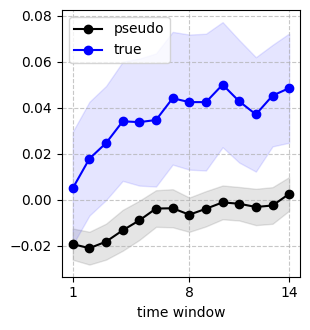

创建了区域 142 的图表


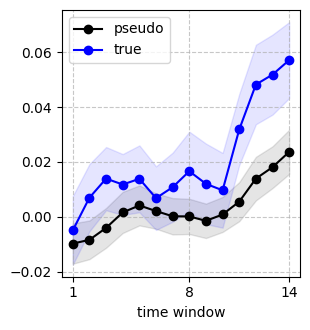

所有图表创建完成


In [9]:
import matplotlib.pyplot as plt
import numpy as np

regions = [66, 142]

for region in regions:
    plt.figure(figsize=(3.2, 3.4))
    
    mean_values1 = np.mean(diagonal_values_avgpair, axis=2)[region][9:]
    se_values1 = np.std(diagonal_values_avgpair, axis=2)[region][9:] / (np.sqrt(diagonal_values_avgpair.shape[2])-1)
    x1 = np.arange(1, len(mean_values1) + 1)
    plt.plot(x1, mean_values1, marker='o', linestyle='-', color='k', label='pseudo')
    plt.fill_between(x1, mean_values1 - se_values1, mean_values1 + se_values1, color='k', alpha=0.1)
    
    mean_values3 = np.mean(diagonal_values_avg, axis=2)[region][9:]
    se_values3 = np.std(diagonal_values_avg, axis=2)[region][9:] / (np.sqrt(diagonal_values_avg.shape[2])-1)
    x3 = np.arange(1, len(mean_values3) + 1)
    plt.plot(x3, mean_values3, marker='o', linestyle='-', color='b', label='true')
    plt.fill_between(x3, mean_values3 - se_values3, mean_values3 + se_values3, color='b', alpha=0.1)
    
    plt.xlabel('time window')
    plt.xticks([x1[0], x1[len(x1)//2], x1[-1]])
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig(f'sl{region}new.png', dpi=300, bbox_inches='tight')
    print(f"创建了区域 {region} 的图表")
    
    plt.show()

print("所有图表创建完成")